# Resource Usage Plots

In [103]:
import pandas as pd
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import os 
os.makedirs('resource_usage_fig', exist_ok=True)
import numpy as np

# Define order for methods
order = ['naive_8um', 'cellpose_cyto3', 'bin2cell_cyto', 'stardist_nuclei',
    'stardist_proximity', 'stardist_voronoi', 'STP_tuned', 'STP_untuned',
    'cellpose_nuclei', 'cellpose_proximity', 'cellpose_voronoi']
samples = ['mouse_intestine', 'mouse_kidney', 'human_colon', 'human_lung', 'mouse_embryo', 'mouse_brain']

# Define method combinations
merge_map = {
    'stardist_proximity': ['stardist_nuclei', 'stardist_proximity'],
    'stardist_voronoi': ['stardist_nuclei', 'stardist_voronoi'],
    'cellpose_voronoi': ['cellpose_nuclei', 'cellpose_voronoi'],
    'cellpose_proximity': ['cellpose_nuclei', 'cellpose_proximity']
}

method_map = {
    'naive_8um': 'Naive 8um',
    'stardist_proximity': 'StarDist + Proximity',
    'stardist_voronoi': 'StarDist + Mask + Voronoi',
    'stardist_nuclei': 'StarDist Nuclei',
    'cellpose_proximity': 'Cellpose + Proximity',
    'cellpose_voronoi': 'Cellpose + Mask + Voronoi',
    'cellpose_cyto3': 'Cellpose3 Cytoplasm',
    'cellpose_nuclei': 'Cellpose Nuclei',
    'bin2cell_cyto': 'Bin2Cell Cytoplasm',
    'STP_tuned': 'STP Tuned',
    'STP_untuned': 'STP Untuned',
}

all_dfs = []  # list to store each sample's dataframe

for sample in samples:
    # Directory containing sample CSV files
    csv_dir = f"/uufs/chpc.utah.edu/common/home/u1531817/20250523_cell_seg_eval/analysis/{sample}/{sample}_run/resource_usage"
    
    # Get all CSV filenames
    csv_files = [os.path.join(csv_dir, f) for f in os.listdir(csv_dir) if f.endswith('.csv')]
    
    # Read and concatenate all CSVs for this sample
    dfs = [pd.read_csv(f, index_col=0) for f in csv_files]  # assuming first column is the index
    df = pd.concat(dfs)
    
    # Keep only the ordered subset that exists in the current DataFrame
    existing_order = [method for method in order if method in df.index]
    df_ordered = df.loc[existing_order].copy()
    
    # Add sample column
    df_ordered['sample'] = sample

    # Make a copy to avoid modifying original
    df_ordered['plot_seg_time'] = df_ordered['segmentation_time']
    df_ordered['plot_peak_mem'] = df_ordered['cpu_peak']
    df_ordered['plot_peak_GPU_memory_usage'] = df_ordered[['torch_peak', 'tensorflow_peak']].max(axis=1)

    # merge multi step values
    for new_method, components in merge_map.items():
        subset = df_ordered[df_ordered.index.isin(components)]
        summed_time = subset['segmentation_time'].sum()
        df_ordered.loc[df_ordered.index == new_method, 'plot_seg_time'] = summed_time
        max_mem = subset['cpu_peak'].max()
        df_ordered.loc[df_ordered.index == new_method, 'plot_peak_mem'] = max_mem

        # Get row-wise max between torch_peak and tensorflow_peak, then take the overall max
        max_gpu = subset[['torch_peak', 'tensorflow_peak']].max(axis=1).max()

        df_ordered.loc[df_ordered.index == new_method, 'plot_peak_GPU_memory_usage'] = max_gpu
        #max_gpu = subset[['torch_peak', 'tensorflow_peak']].max().max()
        #df_ordered.loc[df_ordered.index == new_method, 'plot_peak_GPU_memory_usage'] = max_gpu
    # Append to list
    all_dfs.append(df_ordered)

# Combine all samples into one DataFrame
combined_df = pd.concat(all_dfs)

# Reset index to have a 'method' column for plotting
combined_df = combined_df.reset_index().rename(columns={'index': 'method'})



In [112]:
combined_df

,method,torch_gpu_before,torch_peak,torch_after,segmentation_time,tensorflow_peak,cpu_peak,sample,plot_seg_time,plot_peak_mem,plot_peak_GPU_memory_usage
0,Naive 8um,0.0,0.000000,0.000000,0.233032,0.000000,8726.445312,mouse_intestine,0.233032,8726.445312,0.000000
1,Cellpose3 Cytoplasm,0.0,579.498496,141.490176,10.928391,0.000000,3816.160156,mouse_intestine,10.928391,3816.160156,579.498496
2,Bin2Cell Cytoplasm,0.0,0.000000,0.000000,1958.317619,0.000000,22847.925781,mouse_intestine,1958.317619,22847.925781,0.000000
3,StarDist Nuclei,0.0,0.000000,0.000000,26.960949,6415.446528,15673.800781,mouse_intestine,26.960949,15673.800781,6415.446528
4,StarDist + Proximity,0.0,0.000000,0.000000,18.350195,0.000000,12353.398438,mouse_intestine,45.311144,15673.800781,6415.446528
...,...,...,...,...,...,...,...,...,...,...,...
61,STP Tuned,0.0,1558.545920,0.000000,862.335541,0.000000,16828.472656,mouse_brain,862.335541,16828.472656,1558.545920
62,STP Untuned,0.0,2250.940928,0.000000,724.589864,0.000000,18029.921875,mouse_brain,724.589864,18029.921875,2250.940928
63,Cellpose Nuclei,0.0,558.398976,41.404416,7.407321,0.000000,14438.925781,mouse_brain,7.407321,14438.925781,558.398976
64,Cellpose + Proximity,0.0,0.000000,0.000000,4.278902,0.000000,12237.078125,mouse_brain,11.686222,14438.925781,558.398976


In [108]:
combined_df['method'] = combined_df['method'].map(method_map)


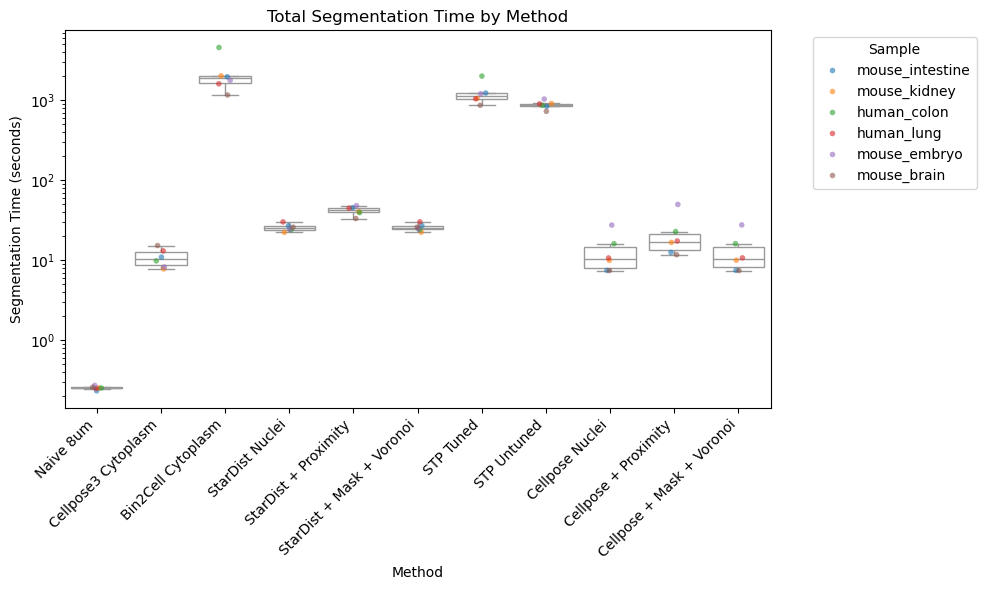

In [109]:
# --- Plotting ---
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=combined_df,
    x='method',
    y=f'plot_seg_time',
    color='white', 
    showfliers=False  
)

sns.stripplot(
    data=combined_df,
    x='method',
    y=f'plot_seg_time',
    hue='sample',  
    size=4,
    alpha=0.6,
    jitter=True,
    palette='tab10' 
)
plt.legend(title='Sample', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title(f'Total Segmentation Time by Method')
plt.xlabel('Method')
plt.ylabel('Segmentation Time (seconds)')
plt.yscale('log')  
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('resource_usage_fig/segmentation_time_boxplot.pdf')
plt.show()


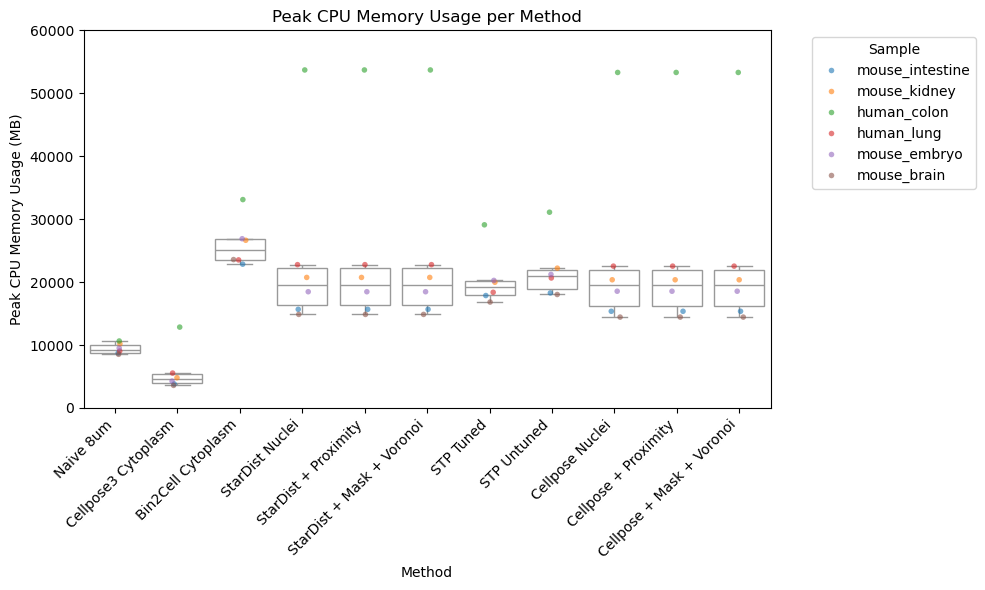

In [110]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=combined_df,
    x='method',
    y=f'plot_peak_mem',
    color='white', 
    showfliers=False  
)

sns.stripplot(
    data=combined_df,
    x='method',
    y=f'plot_peak_mem',
    hue='sample',  
    size=4,
    alpha=0.6,
    jitter=True,
    palette='tab10' 
)
plt.legend(title='Sample', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title(f'Peak CPU Memory Usage per Method')
plt.xlabel('Method')
plt.ylabel(f'Peak CPU Memory Usage (MB)')
#plt.yscale('log')  
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.ylim(0, 60000)
plt.savefig('resource_usage_fig/cpu_peak_boxplot.pdf')
plt.show()


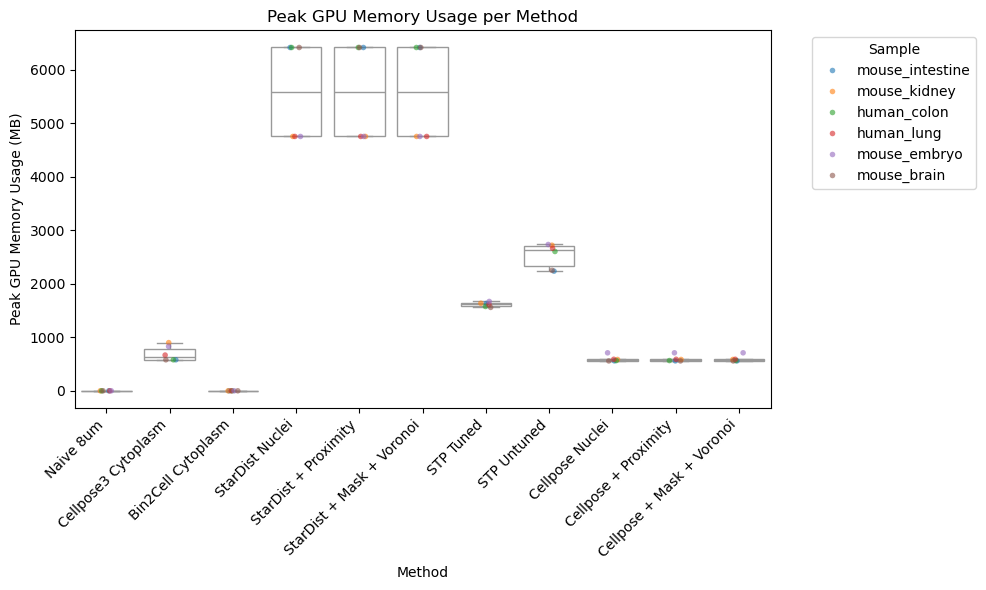

In [111]:
# --- Plotting ---
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=combined_df,
    x='method',
    y='plot_peak_GPU_memory_usage',
    color='white', 
    showfliers=False  
)

sns.stripplot(
    data=combined_df,
    x='method',
    y='plot_peak_GPU_memory_usage',
    hue='sample',  
    size=4,
    alpha=0.6,
    jitter=True,
    palette='tab10' 
)
plt.legend(title='Sample', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title(f'Peak GPU Memory Usage per Method')
plt.xlabel('Method')
plt.ylabel('Peak GPU Memory Usage (MB)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('resource_usage_fig/gpu_peak_boxplot.pdf')
plt.show()
